In [ ]:
# how to clean data from a csv
# feature importance plots
# copy the data and do regression
# feed each column labels into an LLM

In [26]:
pip -q install -U ai-data-science-team langchain langchain-openai openai


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.1/158.1 kB 12.2 MB/s eta 0:00:00


In [64]:
import pandas as pd

df_raw = pd.read_csv("Messy Data - Closed Won - Routing.csv")


In [67]:
import pandas as pd

issues = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing_%": (df_raw.isna().mean() * 100).round(1),
    "unique": df_raw.nunique(dropna=True),
}).sort_values("missing_%", ascending=False)

issues


,dtype,missing_%,unique
Expiring ARR,object,31.0,2025
Contract Date Range,object,3.6,3120
Description,object,0.2,377
Opportunity Type,object,0.0,5
Close Date,object,0.0,1465
Opportunity Owner,object,0.0,96
Account Segment,object,0.0,2
Contract End Date,object,0.0,1547
Contract Start Date,object,0.0,1557
Quote Line ID,object,0.0,8668


In [128]:
quantitative = []
categorical = []
textual = []
temporal = []

date_cols = ['Close Date', 'Contract Start Date', 'Contract End Date']
id_cols = ['Quote Number', 'Quote Line ID', 'Opportunity : Account Name : Account ID']

for c in df_raw.columns:

    if c in date_cols:
        temporal.append(c)
        continue

    if c in id_cols:
        categorical.append(c)
        continue

    if df_raw[c].dtype == "object":

        frac_num = pd.to_numeric(
            df_raw[c].astype(str).str.replace(",", "").str.replace("$",""),
            errors="coerce"
        ).notna().mean()

        nunique = df_raw[c].nunique()

        if frac_num > 0.6: # Adjusted threshold to 0.6
            quantitative.append(c)
        elif nunique < 200:   # higher threshold for business categories
            categorical.append(c)
        else:
            textual.append(c)

    else:
        quantitative.append(c)

print("Quantitative:", quantitative)
print("Categorical:", categorical)
print("Textual:", textual)
print("Temporal:", temporal)


Quantitative: ['Contract Term', 'Customer Unit Price', 'Quantity', 'Customer Total', 'Customer Amount', 'Quote ARR', 'Expiring ARR', 'Growth ARR', 'Quote Line ARR', 'Close Year']
Categorical: ['Account Segment', 'Opportunity Owner', 'Opportunity Type', 'Quote Number', 'Quote Line ID', 'Product Name', 'Product Family', 'Opportunity : Account Name : Account ID']
Textual: ['Contract Date Range', 'Description']
Temporal: ['Close Date', 'Contract Start Date', 'Contract End Date']


In [154]:
import os
from google.colab import userdata

api_key = userdata.get("OPENAI_API_KEY")
print("Key loaded:", api_key is not None)



Key loaded: True


In [28]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
print(llm.invoke("Say hi in one short sentence.").content)


Hi there!


In [30]:
import pandas as pd
from ai_data_science_team.agents import DataCleaningAgent

In [31]:

from google.colab import files
uploaded = files.upload()

Saving Messy Data - Closed Won - Routing.csv to Messy Data - Closed Won - Routing.csv


In [32]:
df = pd.read_csv("Messy Data - Closed Won - Routing.csv")

In [50]:
import pandas as pd
from ai_data_science_team.agents import DataCleaningAgent
from langchain_core.messages import HumanMessage


agent = DataCleaningAgent(model=llm,
                          n_samples=20,
                          log=True, # Enable logging for debugging
                          human_in_the_loop=False)

from langchain_core.messages import HumanMessage

agent.invoke_messages(
    messages=[HumanMessage(content="""
Write the cleaning function using only pandas and numpy.
Do not import scikit-learn or scipy.
Impute numeric missing values with median and categorical with mode.
Do not remove outliers. Do not drop rows.
Only drop columns with >80% missing values.
""")],
    data_raw=df,
    max_retries=2,
    retry_count=0,
)

cleaned = agent.get_data_cleaned()
cleaned.head()

---DATA CLEANING AGENT----
    * RECOMMEND CLEANING STEPS
    * CREATE DATA CLEANER CODE
      File saved to: /content/logs/data_cleaner.py
    * EXECUTE DATA CLEANER CODE (SANDBOXED)
      Error logged to: /content/logs/data_cleaner.py_errors.log
      Error logged to: /content/logs/data_cleaner.py_errors.log
    * FIX AGENT CODE
      retry_count:0
      File saved to: /content/logs/data_cleaner.py
    * EXECUTE DATA CLEANER CODE (SANDBOXED)
      Error logged to: /content/logs/data_cleaner.py_errors.log
      Error logged to: /content/logs/data_cleaner.py_errors.log
    * FIX AGENT CODE
      retry_count:1
      File saved to: /content/logs/data_cleaner.py
    * EXECUTE DATA CLEANER CODE (SANDBOXED)
      Error logged to: /content/logs/data_cleaner.py_errors.log
      Error logged to: /content/logs/data_cleaner.py_errors.log
    * REPORT AGENT OUTPUTS


""


In [51]:
agent.get_recommended_cleaning_steps(markdown=True)
agent.get_data_cleaner_function(markdown=True)
agent.get_workflow_summary(markdown=True)
agent.get_log_summary(markdown=True)
agent.response["data_cleaner_function_path"]


'/content/logs/data_cleaner.py'

In [53]:
path = agent.response["data_cleaner_function_path"]
print(open(path, "r").read())



# Disclaimer: This function was generated by AI. Please review before using.
# Agent Name: data_cleaning_agent
# Time Created: 2026-02-17 06:34:59

def data_cleaner(data_raw):
    import pandas as pd
    import numpy as np
    from sklearn.impute import SimpleImputer



    # Step 1: Remove Columns with Excessive Missing Values
    threshold = 0.8 * len(data_raw)
    data_cleaned = data_raw.dropna(axis=1, thresh=threshold)

    # Step 2: Impute Missing Values for Numeric Columns
    numeric_cols = data_cleaned.select_dtypes(include=['float64', 'int64']).columns
    imputer_numeric = SimpleImputer(strategy='median')
    data_cleaned[numeric_cols] = imputer_numeric.fit_transform(data_cleaned[numeric_cols])

    # Step 3: Impute Missing Values for Categorical Columns
    categorical_cols = data_cleaned.select_dtypes(include=['object']).columns
    imputer_categorical = SimpleImputer(strategy='most_frequent')
    data_cleaned[categorical_cols] = imputer_categorical.fit_transform(data_clean

In [137]:
exec(open(path).read(), globals())


In [147]:
df_clean = data_cleaner(df_raw.copy(deep=True))


/tmp/ipython-input-1393767953.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.loc[:, col] = pd.to_datetime(df[col], errors="coerce")
/tmp/ipython-input-1393767953.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.loc[:, col] = pd.to_datetime(df[col], errors="coerce")
/tmp/ipython-input-1393767953.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.loc[:, col] = pd.to_datetime(df[col], errors="coerce")
/tmp/ipython-input-1393767953.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure 

In [148]:
df_clean = data_cleaner(df)
df_clean.shape
df_clean

/tmp/ipython-input-1393767953.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.loc[:, col] = pd.to_datetime(df[col], errors="coerce")
/tmp/ipython-input-1393767953.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.loc[:, col] = pd.to_datetime(df[col], errors="coerce")
/tmp/ipython-input-1393767953.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.loc[:, col] = pd.to_datetime(df[col], errors="coerce")
/tmp/ipython-input-1393767953.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure 

,Account Segment,Opportunity Owner,Opportunity Type,Close Date,Contract Date Range,Contract Start Date,Contract End Date,Contract Term,Quote Number,Quote Line ID,...,Customer Unit Price,Quantity,Customer Total,Customer Amount,Quote ARR,Expiring ARR,Growth ARR,Quote Line ARR,Opportunity : Account Name : Account ID,Close Year
0,Commercial,William Bunge,Renewal,2024-08-15 00:00:00,NaT,2024-09-01 00:00:00,2025-08-31 00:00:00,1.0,Q-13765,a4XPL00000046YH,...,408,45,"18,360","18,360","18,360","16,500","1,860","18,360",0013100001Xo0PK,2024
1,Commercial,Joe Day,Renewal,2019-08-30 00:00:00,NaT,2019-09-01 00:00:00,2020-08-31 00:00:00,1.0,Q-02577,a4X5A00000015zV,...,353,30,"10,600","20,600","20,600","20,600",(0),"10,600",0013100001Xo0PK,2019
2,Commercial,Aamer Jomaa,Renewal,2020-08-31 00:00:00,NaT,2020-09-01 00:00:00,2021-08-31 00:00:00,1.0,Q-02578,a4X5A00000015zb,...,353,47,"16,607","41,607","41,607","23,100","18,507","16,607",0013100001Xo0PK,2020
3,Commercial,Carlos Gomez,Renewal,2023-08-18 00:00:00,NaT,2023-09-01 00:00:00,2024-08-31 00:00:00,1.0,Q-08273,a4X6e0000005jB2,...,300,55,"16,500","16,500","16,500","37,000","(20,500)","16,500",0013100001Xo0PK,2023
4,Commercial,Aamer Jomaa,Renewal,2021-08-16 00:00:00,NaT,2021-09-01 00:00:00,2022-08-31 00:00:00,1.0,Q-03793,a4X5A000000g0Sa,...,353,52,"18,377","43,377","43,377","41,607","1,770","18,377",0013100001Xo0PK,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8663,Commercial,Erin McCarty,Renewal,2021-01-28 00:00:00,NaT,2021-02-01 00:00:00,2022-01-31 00:00:00,1.0,Q-04621,a4X5A000000g1vk,...,"1,350",10,"13,500","13,500","13,500","13,500",0,"13,500",001i000001Xne3s,2021
8664,Commercial,Emily Sipes,Renewal,2022-01-13 00:00:00,NaT,2022-02-01 00:00:00,2023-01-31 00:00:00,1.0,Q-04639,a4X5A000000g1x7,...,780,23,"17,940","17,940","17,940","13,500","4,440","17,940",001i000001Xne3s,2022
8665,Commercial,William Bunge,Renewal,2025-02-11 00:00:00,NaT,2025-02-01 00:00:00,2026-01-31 00:00:00,1.0,Q-14253,a4XPL00000052M9,...,708,23,"16,284","16,284","16,284","16,284",0,"16,284",001i000001Xne3s,2025
8666,Commercial,William Bunge,Renewal,2024-05-09 00:00:00,NaT,2024-02-01 00:00:00,2025-01-31 00:00:00,1.0,Q-09160,a4X6e000000Utd3,...,708,23,"16,284","16,284","16,284","16,284",0,"16,284",001i000001Xne3s,2024


In [140]:
import pandas as pd
import numpy as np

target = "Customer Unit Price"

# Start with df_clean and filter rows where target is NaN initially
# This handles cases where df_clean[target] might already have NaNs
df_model_temp = df_clean[df_clean[target].notna()].copy()

# Process y: convert to string, remove commas, strip spaces, then to numeric (coerce errors to NaN)
y_processed = df_model_temp[target].astype(str).str.replace(',', '', regex=False).str.strip()
y_processed = pd.to_numeric(y_processed, errors='coerce')

# Filter out rows where y_processed became NaN
valid_indices = y_processed.notna()
y = y_processed[valid_indices]
df_model_filtered = df_model_temp[valid_indices].copy() # Filter df_model to match y

# Now create X from the filtered df_model
X = df_model_filtered.drop(columns=[target]).copy()

# drop leakage
leakage_cols = [
    "Customer Total", "Customer Amount", "Quote ARR", "Quote Line ARR", "Growth ARR"
]
X = X.drop(columns=leakage_cols, errors="ignore")

# expand dates into numeric features
date_cols_features = ["Close Date", "Contract Start Date", "Contract End Date"]
for c in date_cols_features:
    if c in X.columns:
        # Ensure the column is datetime before accessing dt accessor
        X[c] = pd.to_datetime(X[c], errors="coerce")
        X[c + "_year"] = X[c].dt.year
        X[c + "_month"] = X[c].dt.month

# Drop original date columns
X = X.drop(columns=[c for c in date_cols_features if c in X.columns])
X = X.drop(columns=[
    "Opportunity : Account Name : Account ID",
    "Quote Number",
    "Quote Line ID",
], errors="ignore")


In [141]:
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

date_cols = X.select_dtypes(include=["datetime64[ns]"]).columns.tolist()
def expand_dates(df):
    df = df.copy()
    for c in date_cols:
        df[c + "_year"] = df[c].dt.year
        df[c + "_month"] = df[c].dt.month
    return df.drop(columns=date_cols)

from sklearn.preprocessing import FunctionTransformer
date_transformer = FunctionTransformer(expand_dates)


In [142]:
X_train = X
Y_train = y
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ct = make_column_transformer(
    (date_transformer, date_cols),
    (OneHotEncoder(handle_unknown="ignore"), cat_cols),
    (StandardScaler(), num_cols)
)


In [143]:
import xgboost as xgb
import matplotlib.pyplot as plt



# Initialize and fit the model (using the scikit-learn API)
model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0,
    n_jobs=-1
)

pipeline = make_pipeline(
    ct,
    model
)

pipeline.fit(X_train, Y_train)



Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('functiontransformer',
                                                  FunctionTransformer(func=<function expand_dates at 0x7e006c8400e0>),
                                                  []),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Account Segment',
                                                   'Opportunity Owner',
                                                   'Opportunity Type',
                                                   'Contract Date Range',
                                                   'Product Name',
                                                   'Product Family',
                                                   'Description', 'Quantity',
                                                   'Ex...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [144]:
ohe = pipeline.named_steps['columntransformer']
feature_names = ohe.get_feature_names_out()
importances = pipeline.named_steps['xgbregressor'].feature_importances_


In [145]:
import pandas as pd

imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

def extract_original_col(name):
    # Remove transformer prefixes
    name = name.split("__")[-1]
    # Remove category suffix
    return name.split("_")[0]

imp_df["column"] = imp_df["feature"].apply(extract_original_col)

col_importance = (
    imp_df.groupby("column")["importance"]
    .sum()
    .sort_values(ascending=False)
)

top_cols = col_importance.head(5).index.tolist()
print(top_cols)


['Product Name', 'Opportunity Owner', 'Description', 'Expiring ARR', 'Quantity']


In [150]:
numeric_cols = df_model.select_dtypes(include="number").columns

top_numeric = [c for c in top_cols if c in numeric_cols]
top_numeric

[]

/tmp/ipython-input-3212302927.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


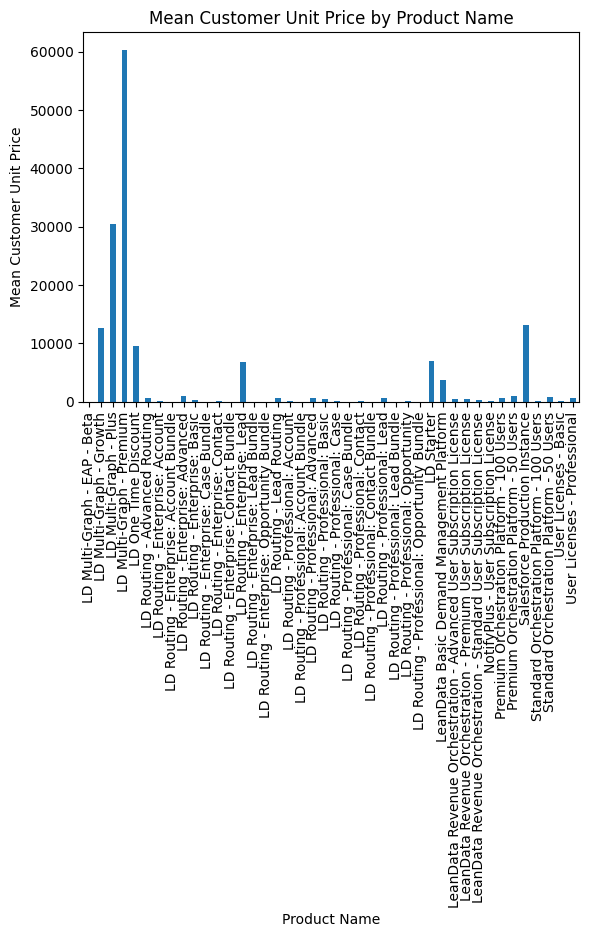

In [136]:
import matplotlib.pyplot as plt

# Ensure the target column is numeric before plotting
df_clean[target] = pd.to_numeric(df_clean[target].astype(str).str.replace(',', '').str.strip(), errors='coerce')

# Drop rows where target became NaN after conversion
df_plot = df_clean.dropna(subset=[target]).copy()

df_plot.groupby("Product Name")[target].mean().plot.bar()
plt.title(f'Mean {target} by Product Name')
plt.xlabel('Product Name')
plt.ylabel(f'Mean {target}')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [61]:
df_clean['Quote Line ARR'].isna().sum()

np.int64(1606)

In [62]:
df_clean.to_csv("cleaned_data.csv", index=False)


In [63]:
from google.colab import files
files.download("cleaned_data.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [58]:
path = agent.response["data_cleaner_function_path"]
print(open(path, "r").read())


# Disclaimer: This function was generated by AI. Please review before using.
# Agent Name: data_cleaning_agent
# Time Created: 2026-02-17 06:34:59

def data_cleaner(data_raw):
    import pandas as pd
    import numpy as np
    from sklearn.impute import SimpleImputer



    # Step 1: Remove Columns with Excessive Missing Values
    threshold = 0.8 * len(data_raw)
    data_cleaned = data_raw.dropna(axis=1, thresh=threshold)

    # Step 2: Impute Missing Values for Numeric Columns
    numeric_cols = data_cleaned.select_dtypes(include=['float64', 'int64']).columns
    imputer_numeric = SimpleImputer(strategy='median')
    data_cleaned[numeric_cols] = imputer_numeric.fit_transform(data_cleaned[numeric_cols])

    # Step 3: Impute Missing Values for Categorical Columns
    categorical_cols = data_cleaned.select_dtypes(include=['object']).columns
    imputer_categorical = SimpleImputer(strategy='most_frequent')
    data_cleaned[categorical_cols] = imputer_categorical.fit_transform(data_clean

In [49]:
# 1) get the generated cleaning function code
code = agent.get_data_cleaner_function(markdown=False)

# 2) define it in your notebook (outside the sandbox)
exec(code, globals())

# 3) run it on your dataframe
df_clean = data_cleaner(df)  # replace df with whatever you passed in
df_clean.shape, df_clean.head()


Account Segment                             object
Opportunity Owner                           object
Opportunity Type                            object
Close Date                                  object
Contract Date Range                         object
Contract Start Date                         object
Contract End Date                           object
Contract Term                              float64
Quote Number                                object
Quote Line ID                               object
Product Name                                object
Product Family                              object
Description                                 object
Customer Unit Price                        float64
Quantity                                   float64
Customer Total                             float64
Customer Amount                            float64
Quote ARR                                  float64
Expiring ARR                               float64
Growth ARR                     

((8668, 23),
   Account Segment Opportunity Owner Opportunity Type Close Date  \
 0      Commercial     William Bunge          Renewal    8/15/24   
 1      Commercial           Joe Day          Renewal    8/30/19   
 2      Commercial       Aamer Jomaa          Renewal    8/31/20   
 3      Commercial      Carlos Gomez          Renewal    8/18/23   
 4      Commercial       Aamer Jomaa          Renewal    8/16/21   
 
      Contract Date Range Contract Start Date Contract End Date  Contract Term  \
 0  9/1/2024 to 8/31/2025              9/1/24           8/31/25            1.0   
 1  9/1/2019 to 8/31/2020              9/1/19           8/31/20            1.0   
 2  9/1/2020 to 8/31/2021              9/1/20           8/31/21            1.0   
 3  9/1/2023 to 8/31/2024              9/1/23           8/31/24            1.0   
 4  9/1/2021 to 8/31/2022              9/1/21           8/31/22            1.0   
 
   Quote Number    Quote Line ID  ... Customer Unit Price Quantity  \
 0      Q-137

In [ ]:
df.groupby("Opportunity Type")["Quantity"].plot.hist()

In [6]:
(df["Quote Line ARR"]).isna().mean()

np.float64(0.00046146746654360867)

In [21]:
(df['Quote Line ARR'].apply(type) == str).sum() or df['Quote Line ARR'] == 0 or

np.int64(8664)

In [ ]:
categoricals = ['Account Segment', 'Opportunity Type',
       'Contract Term','Product Family','Close Year']

textuals = ['Product Name','Description']

quantitatives = ['Customer Unit Price','Quantity', 'Customer Total', 'Customer Amount', 'Quote ARR',
       'Expiring ARR', 'Growth ARR', 'Quote Line ARR']

all_vars = categoricals + textuals + quantitatives
all_vars

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import pairwise_distances
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsRegressor
import numpy as np
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

# Define the label and feature lists
label = 'Price'

# Create a new quantitatives list excluding the label
quantitatives_for_transformer = [col for col in quantitatives if col != label]

ct = make_column_transformer(
      (StandardScaler(), quantitatives_for_transformer),
      (TfidfVectorizer(max_features=100), textuals),
      (OneHotEncoder(handle_unknown="ignore"), categoricals)
)

X_train = df[[col for col in all_vars if col != label]]
Y_train = df[label]

pipeline = make_pipeline(
    ct,
    GradientBoostingRegressor()
)

grid_search = GridSearchCV(
    pipeline,
    param_grid = {"gradientboostingregressor__n_estimators": [50, 100, 150]},
    cv = 4,
    scoring = "r2"
)

grid_search.fit(X = X_train, y = Y_train)
# grid_search.predict(X = X_test) # Removed as X_test is not defined